In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pickle
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('All libraries loaded!')


All libraries loaded!


In [2]:
# IMPORTANT: sep='\t' because the file is tab-separated
df = pd.read_csv('data/marketing_campaign.csv', sep='\t')
print('Shape:', df.shape)
print('\nAll columns:')
for i, col in enumerate(df.columns):
    print(f'  {i+1:2}. {col}')


Shape: (2240, 29)

All columns:
   1. ID
   2. Year_Birth
   3. Education
   4. Marital_Status
   5. Income
   6. Kidhome
   7. Teenhome
   8. Dt_Customer
   9. Recency
  10. MntWines
  11. MntFruits
  12. MntMeatProducts
  13. MntFishProducts
  14. MntSweetProducts
  15. MntGoldProds
  16. NumDealsPurchases
  17. NumWebPurchases
  18. NumCatalogPurchases
  19. NumStorePurchases
  20. NumWebVisitsMonth
  21. AcceptedCmp3
  22. AcceptedCmp4
  23. AcceptedCmp5
  24. AcceptedCmp1
  25. AcceptedCmp2
  26. Complain
  27. Z_CostContact
  28. Z_Revenue
  29. Response


In [3]:
df.head(5)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
print('=== Data Types ===')
df.info()


=== Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases  

In [5]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal missing: {df.isnull().sum().sum()}')


=== Missing Values ===
Income    24
dtype: int64

Total missing: 24


In [6]:
print('=== Summary Statistics ===')
df.describe()

=== Summary Statistics ===


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


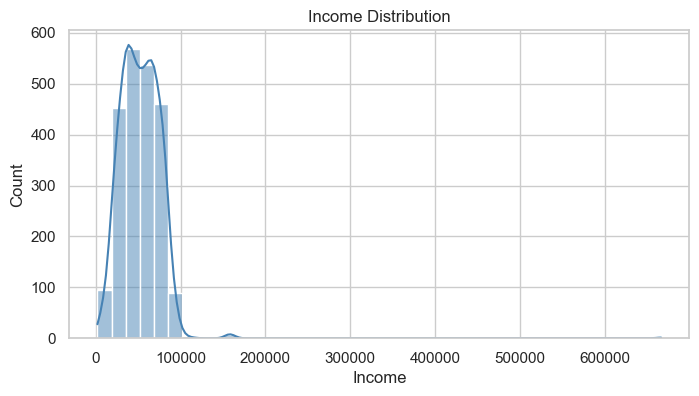

In [7]:
# Income distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Income'].dropna(), bins=40, kde=True, color='steelblue')
plt.title('Income Distribution')
plt.savefig('data/eda_income.png', dpi=150, bbox_inches='tight')
plt.show()


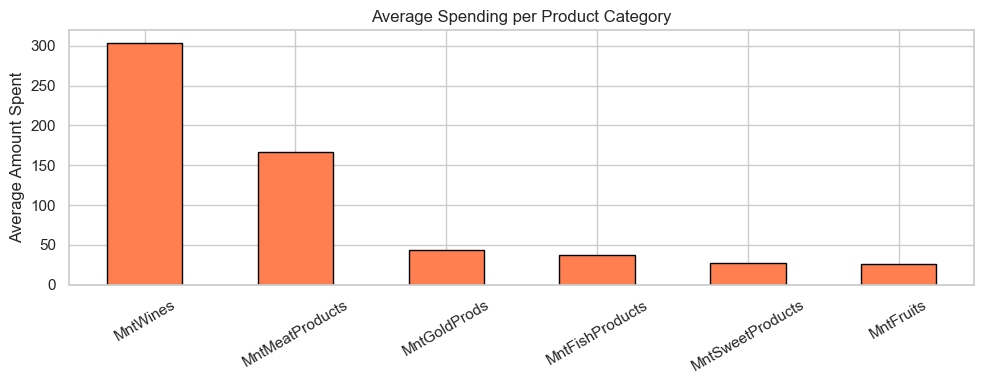

In [8]:
# Spending per product category
spend_cols = ['MntWines','MntFruits','MntMeatProducts',
              'MntFishProducts','MntSweetProducts','MntGoldProds']
plt.figure(figsize=(10, 4))
df[spend_cols].mean().sort_values(ascending=False).plot(
    kind='bar', color='coral', edgecolor='black')
plt.title('Average Spending per Product Category')
plt.ylabel('Average Amount Spent')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('data/eda_spending.png', dpi=150, bbox_inches='tight')
plt.show()


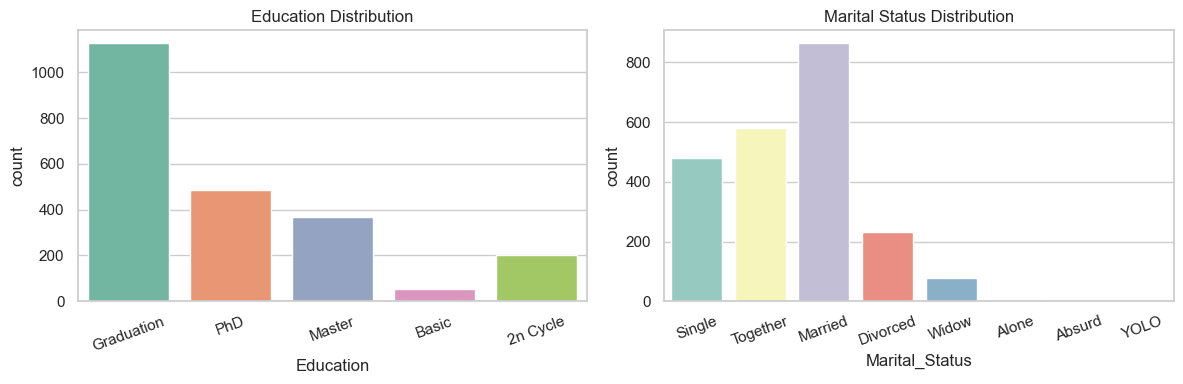

In [9]:
# Education & Marital Status
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Education', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Education Distribution')
axes[0].tick_params(axis='x', rotation=20)
sns.countplot(x='Marital_Status', data=df, ax=axes[1], palette='Set3')
axes[1].set_title('Marital Status Distribution')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('data/eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()


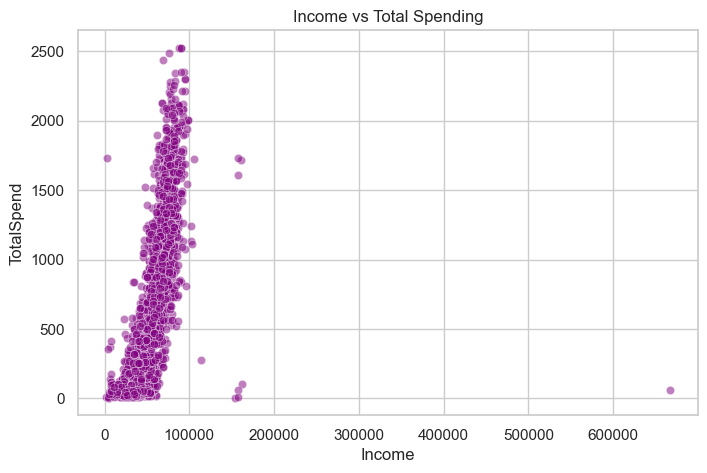

In [10]:
# Income vs Total Spending
df['TotalSpend'] = df[spend_cols].sum(axis=1)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Income', y='TotalSpend', data=df, alpha=0.5, color='purple')
plt.title('Income vs Total Spending')
plt.savefig('data/eda_income_spend.png', dpi=150, bbox_inches='tight')
plt.show()


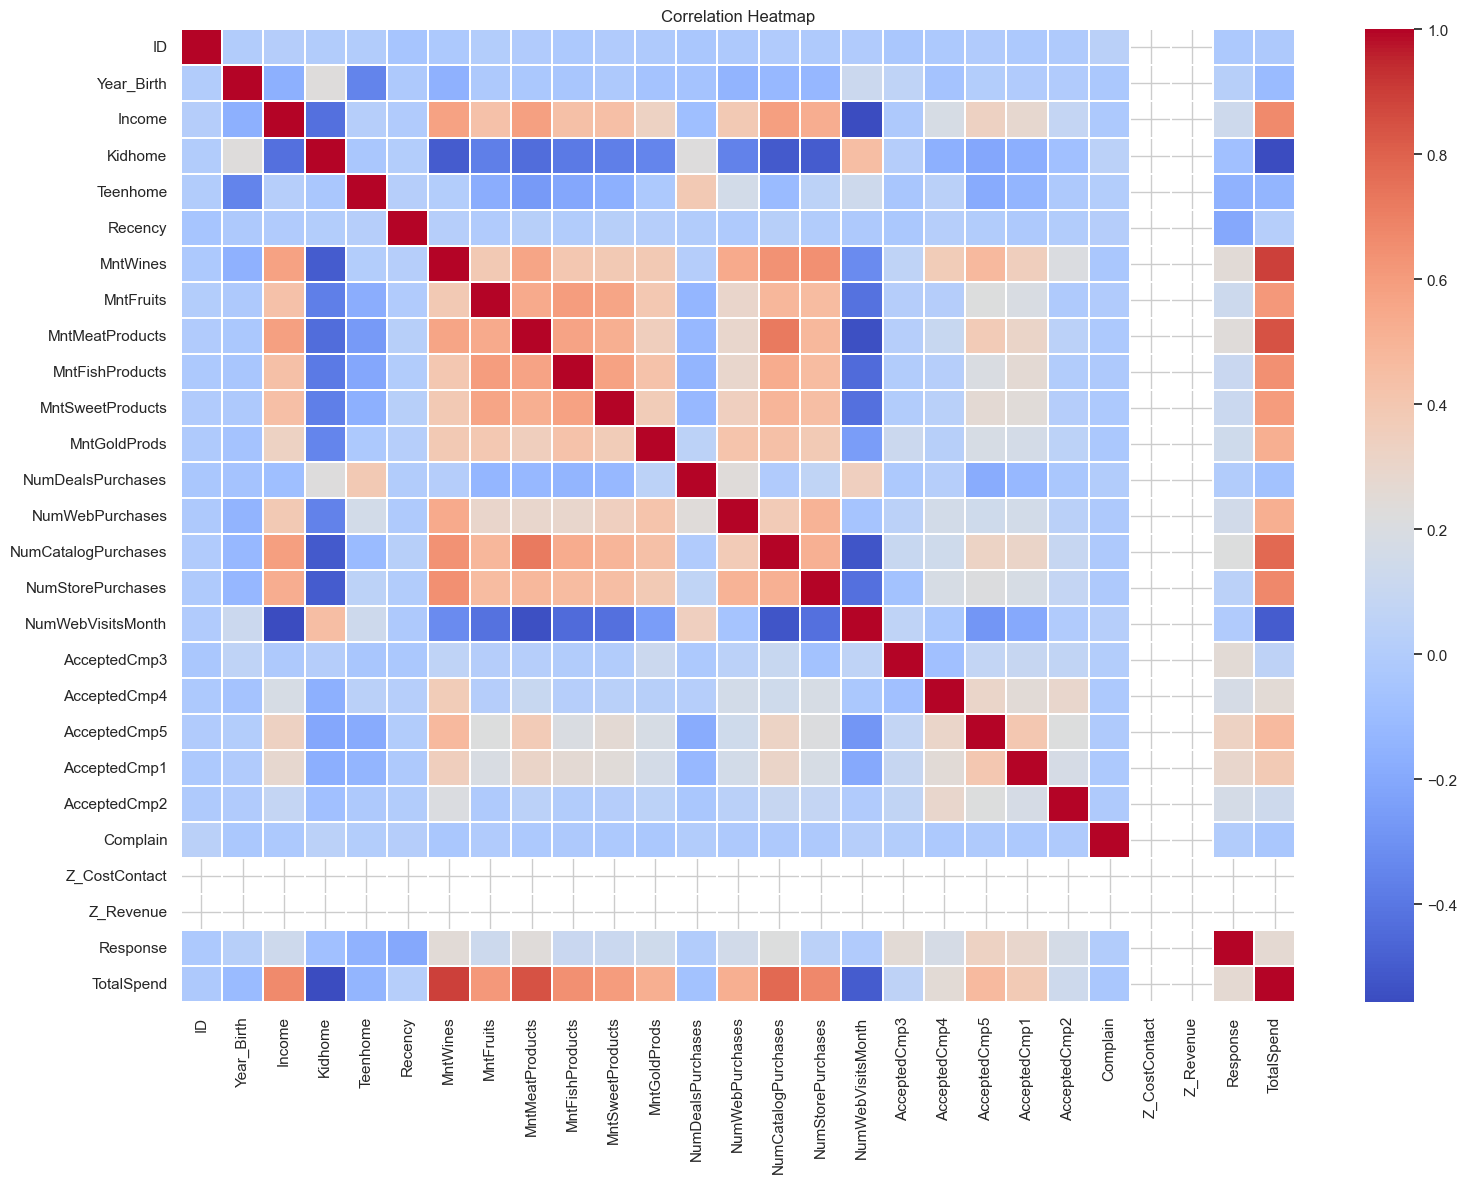

In [11]:
# Correlation heatmap (numeric columns only)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(16, 12))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', linewidths=0.3,
            annot=False)  # too many cols for annot=True
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('data/eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
df_clean = df.copy()

# Age from Year_Birth
df_clean['Age'] = 2024 - df_clean['Year_Birth']

# Total spending across all products
df_clean['TotalSpend'] = (df_clean['MntWines'] + df_clean['MntFruits'] +
                          df_clean['MntMeatProducts'] + df_clean['MntFishProducts'] +
                          df_clean['MntSweetProducts'] + df_clean['MntGoldProds'])

# Total purchases across all channels
df_clean['TotalPurchases'] = (df_clean['NumWebPurchases'] + df_clean['NumCatalogPurchases'] +
                               df_clean['NumStorePurchases'] + df_clean['NumDealsPurchases'])

# Total children
df_clean['TotalChildren'] = df_clean['Kidhome'] + df_clean['Teenhome']

# Days as customer
df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], dayfirst=True)
df_clean['Days_Customer'] = (pd.Timestamp('2024-01-01') - df_clean['Dt_Customer']).dt.days

# Total campaigns accepted
df_clean['TotalAccepted'] = (df_clean['AcceptedCmp1'] + df_clean['AcceptedCmp2'] +
                              df_clean['AcceptedCmp3'] + df_clean['AcceptedCmp4'] +
                              df_clean['AcceptedCmp5'] + df_clean['Response'])

print('New features created: Age, TotalSpend, TotalPurchases, TotalChildren, Days_Customer, TotalAccepted')


New features created: Age, TotalSpend, TotalPurchases, TotalChildren, Days_Customer, TotalAccepted


In [18]:
# Keep only the most useful features for clustering
features = [
    'Age',            # customer age
    'Income',         # yearly income
    'TotalSpend',     # total money spent
    'TotalPurchases', # total number of purchases
    'TotalChildren',  # number of kids + teens
    'Recency',        # days since last purchase
    'Days_Customer',  # how long they've been a customer
    'TotalAccepted',  # how many campaigns accepted
    'NumWebVisitsMonth' # web visits per month
]

df_model = df_clean[features].copy()
print('Features selected for clustering:')
print(df_model.columns.tolist())
print('\nShape:', df_model.shape)


Features selected for clustering:
['Age', 'Income', 'TotalSpend', 'TotalPurchases', 'TotalChildren', 'Recency', 'Days_Customer', 'TotalAccepted', 'NumWebVisitsMonth']

Shape: (2240, 9)


In [19]:
# Fill Income missing with median
df_model['Income'] = df_model['Income'].fillna(df_model['Income'].median())
print('Missing values after fill:', df_model.isnull().sum().sum())

# Remove extreme outliers (3 standard deviations)
before = len(df_model)
for col in ['Income', 'Age', 'TotalSpend']:
    mean, std = df_model[col].mean(), df_model[col].std()
    df_model = df_model[(df_model[col] >= mean - 3*std) &
                        (df_model[col] <= mean + 3*std)]
df_model = df_model.reset_index(drop=True)
print(f'Rows: {before} → {len(df_model)} (removed {before - len(df_model)} outliers)')


Missing values after fill: 0
Rows: 2240 → 2224 (removed 16 outliers)


In [20]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)
print('Scaling done! Shape:', df_scaled.shape)


Scaling done! Shape: (2224, 9)


PCA variance explained: 51.9%


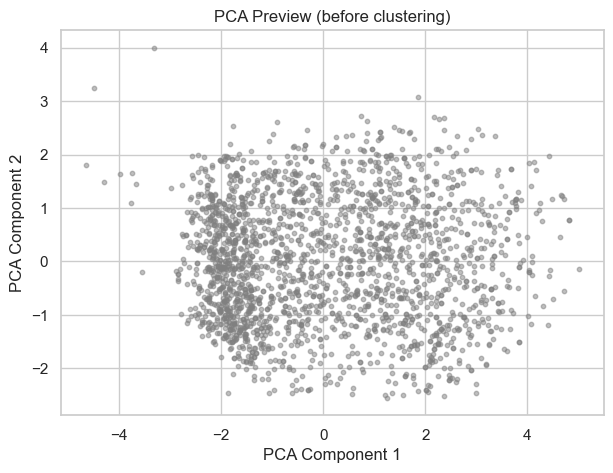

In [21]:
# PCA for visualisation
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)
print(f'PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

plt.figure(figsize=(7, 5))
plt.scatter(df_pca[:, 0], df_pca[:, 1], s=10, alpha=0.5, color='gray')
plt.title('PCA Preview (before clustering)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.savefig('data/eda_pca_preview.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
pickle.dump(df_scaled, open('data/df_scaled.pkl', 'wb'))
pickle.dump(df_model,  open('data/df_clean.pkl',  'wb'))
pickle.dump(scaler,    open('data/scaler.pkl',    'wb'))
pickle.dump(df_pca,    open('data/df_pca.pkl',    'wb'))
pickle.dump(features,  open('data/features.pkl',  'wb'))

print('Saved:')
print('  df_scaled.pkl  — scaled data for clustering')
print('  df_clean.pkl   — clean data (original scale)')
print('  scaler.pkl     — scaler (needed to transform new input later)')
print('  df_pca.pkl     — 2D PCA for plotting')
print('  features.pkl   — feature names list')
print(f'\nFinal shape: {df_scaled.shape}')
print('\nDone! Now run notebooks 02, 03, 04.')


Saved:
  df_scaled.pkl  — scaled data for clustering
  df_clean.pkl   — clean data (original scale)
  scaler.pkl     — scaler (needed to transform new input later)
  df_pca.pkl     — 2D PCA for plotting
  features.pkl   — feature names list

Final shape: (2224, 9)

Done! Now run notebooks 02, 03, 04.


In [23]:
pickle.dump(df_scaled, open('data/df_scaled.pkl', 'wb'))
pickle.dump(df_model,  open('data/df_clean.pkl',  'wb'))
pickle.dump(scaler,    open('data/scaler.pkl',    'wb'))
pickle.dump(df_pca,    open('data/df_pca.pkl',    'wb'))
pickle.dump(features,  open('data/features.pkl',  'wb'))

print('Saved:')
print('  df_scaled.pkl  — scaled data for clustering')
print('  df_clean.pkl   — clean data (original scale)')
print('  scaler.pkl     — scaler (needed to transform new input later)')
print('  df_pca.pkl     — 2D PCA for plotting')
print('  features.pkl   — feature names list')
print(f'\nFinal shape: {df_scaled.shape}')
print('\nDone! Now run notebooks 02, 03, 04.')


Saved:
  df_scaled.pkl  — scaled data for clustering
  df_clean.pkl   — clean data (original scale)
  scaler.pkl     — scaler (needed to transform new input later)
  df_pca.pkl     — 2D PCA for plotting
  features.pkl   — feature names list

Final shape: (2224, 9)

Done! Now run notebooks 02, 03, 04.
